# Mini tutorial de usar HEALPix 

[LINK TUTORIAL HEALpy](https://www.zonca.dev/posts/2020-09-30-planck-spectra-healpy.html)


[Documentacion Healpy](https://healpy.readthedocs.io/en/latest/healpy_rotator.html)

In [37]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import pysm3 as pysm
import pysm3.units as u
import camb
import pandas as pd


In [8]:
## Healpix divide la esfera en 12 trozos 

# nside2npix: retorna la resolucion del mapa Npix = 12*Nside^2 

nside = 512 # son los pixeles de 1 trozo
npix = hp.nside2npix(nside) # son la cantidad de pixeles  en la esfera completa o mapa.
print(npix)


3145728


setting the output map dtype to [dtype('float64')]


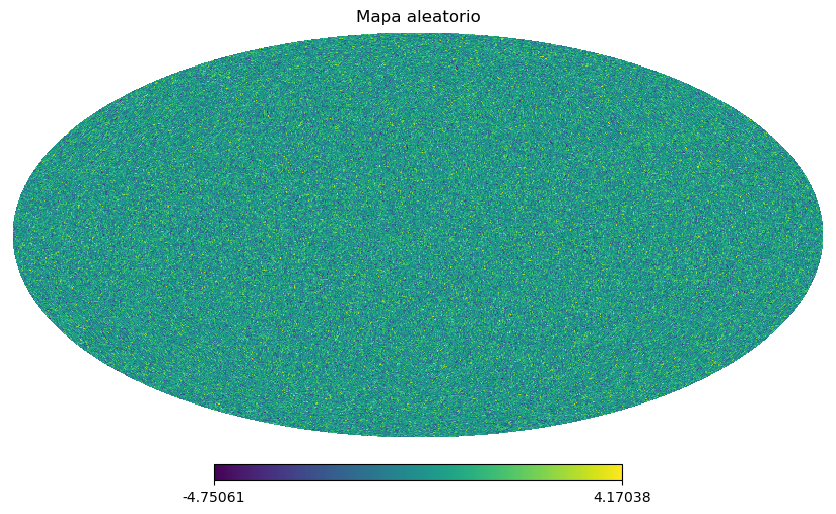

In [ ]:
## Crear un mapa aleatorio

nside = 128
m = np.random.normal(size=hp.nside2npix(nside))
hp.mollview(m, title="Mapa aleatorio")

hp.write_map("mi_mapa.fits", m, overwrite=True) # guardar el archivo como .fits

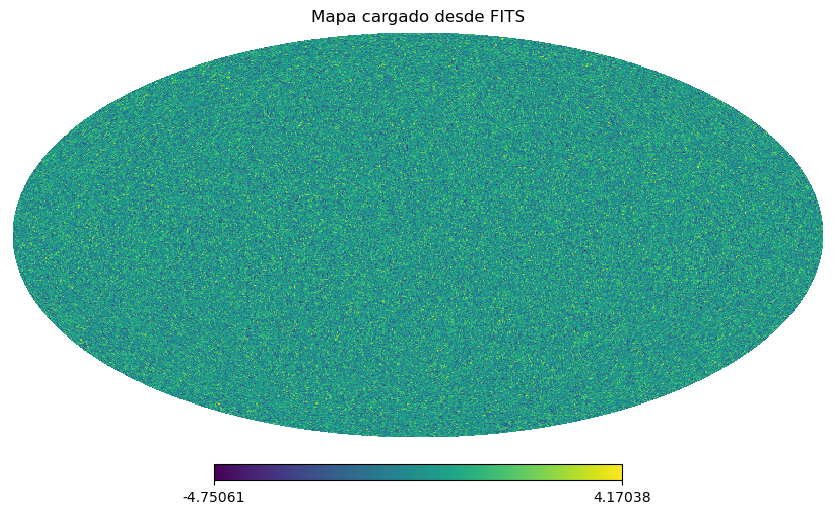

In [10]:
## Leer un mapa FITS

m = hp.read_map("mi_mapa.fits")
hp.mollview(m, title="Mapa cargado desde FITS")

## COMO SERIA PARA MAPAS DE POLARIZACION????

In [11]:
## Convertir alm <--> a mapas

alms = hp.map2alm(m) # mapa --> alms

m_rec = hp.alm2map(alms, nside) # alms --> mapa

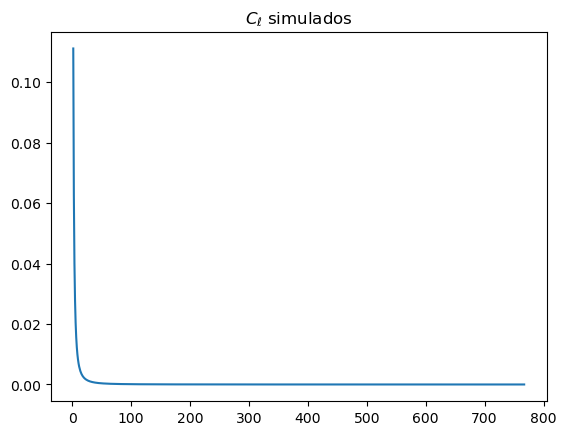

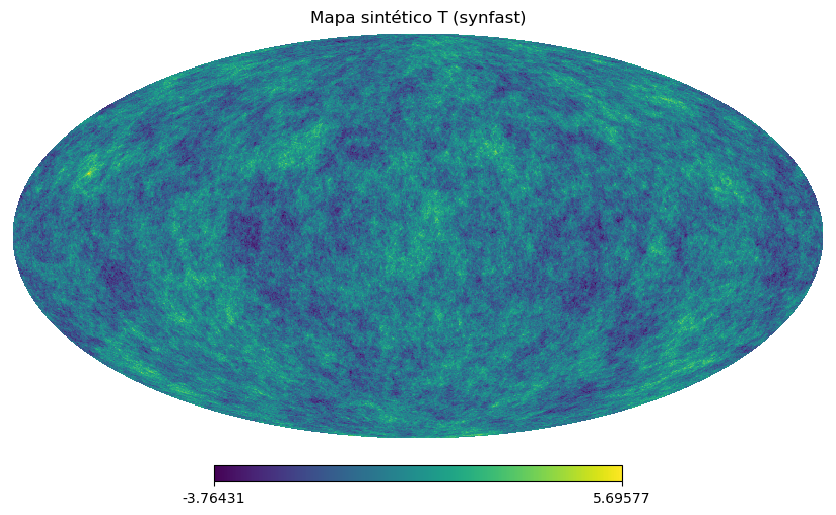

In [ ]:
## Generar un mapa a partir de los CLs de un espectro synfast
# Aca para que no cambie el mapa simulado hay que fijar la semilla

np.random.seed(1234) #fijamos la semilla 

nside = 256
lmax = 3*nside - 1

# Creamos un espectro Cl simple como ejemplo:
ells = np.arange(lmax + 1)
cl_tt = 1 / (ells+1)**2  
cl_tt[0:2] = 0  # evitar infinidades
plt.plot(ells[2:], cl_tt[2:])
plt.title(r'$C_{\ell}$ simulados')


# Generar mapa T
m = hp.synfast(cl_tt, nside=nside, lmax=lmax)

hp.mollview(m, title="Mapa sintético T (synfast)")


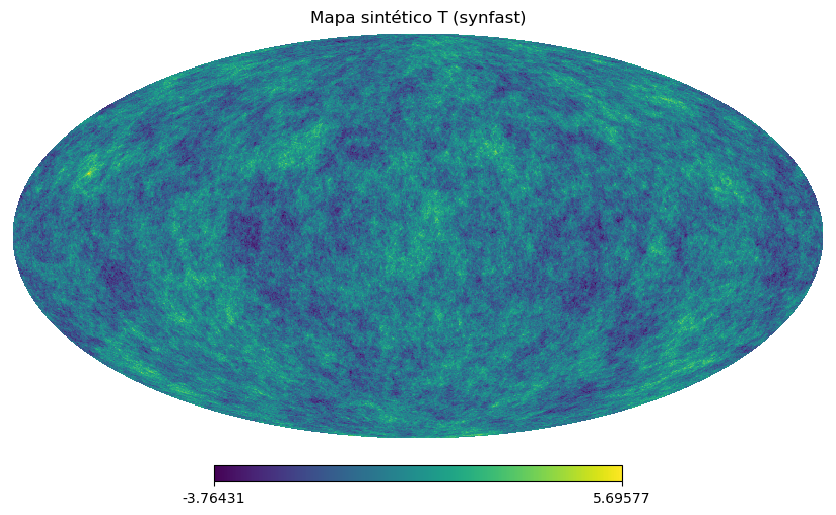

In [13]:
## Generar alms (aleatorios) desde los CLs con synalm

#usamos ejemplo anterior
alm = hp.synalm(cl_tt, lmax=lmax)

m_rec = hp.alm2map(alm, nside=nside) # paso de als --> mapa

hp.mollview(m, title="Mapa sintético T (synfast)")

Text(0.5, 1.0, '$C_{\\ell}$')

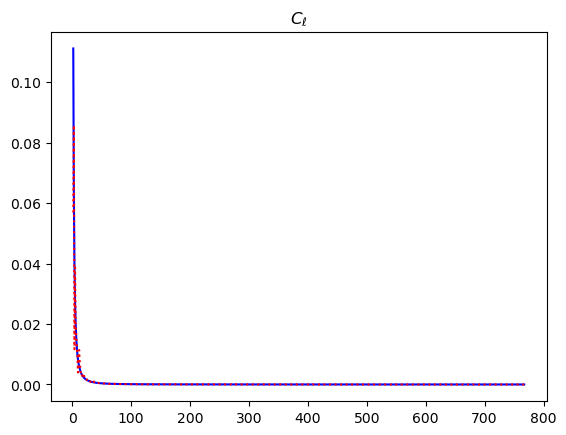

In [14]:
## Calcular los Cls de un mapa

cl_est = hp.anafast(m, lmax=lmax)

plt.plot(ells[2:], cl_tt[2:], color='b')
plt.plot(ells[2:], cl_est[2:], color='r', linestyle=':')
plt.title(r'$C_{\ell}$')


/home/jorge/miniconda3/envs/cosmo39/lib/python3.9/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: divide by zero encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)
/home/jorge/miniconda3/envs/cosmo39/lib/python3.9/site-packages/healpy/pixelfunc.py:529: RuntimeWarning: invalid value encountered in _pix2ang_ring
  theta, phi = pixlib._pix2ang_ring(nside, ipix)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 786432 but corresponding boolean dimension is 3145728

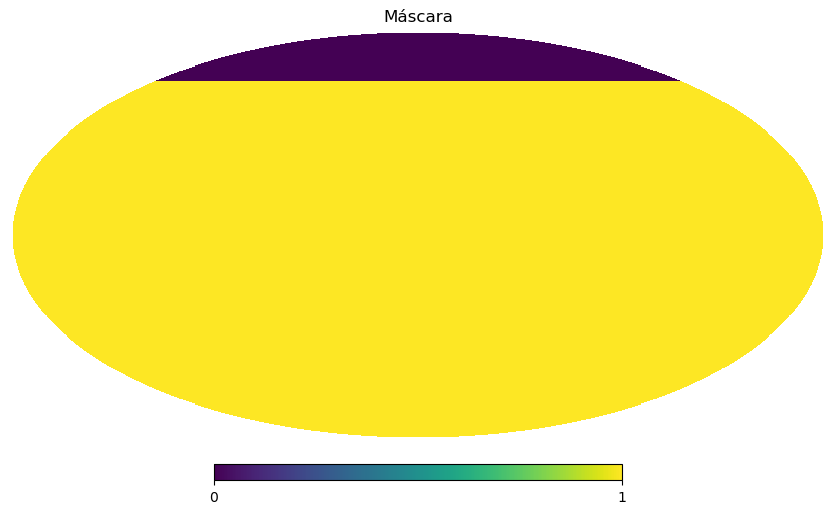

In [15]:
## Hacer mascaras (REVISAR)

mask = np.ones(hp.nside2npix(nside))
theta, phi = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))

mask[theta < np.radians(30)] = 0  # eliminar región polar

hp.mollview(mask, title="Máscara")

###(a) Máscara simple de corte galáctico

# latitud galáctica
theta, phi = hp.pix2ang(nside, np.arange(npix), lonlat=False)
b = np.pi/2 - theta  # latitud galáctica en radianes

# corta la galaxia ±20 deg
mask[np.abs(b) < np.deg2rad(20)] = 0

hp.mollview(mask, title="Máscara galáctica |b|>20°")

###(b) Máscara estilo telescopio: "patch" observado
ra0 = np.deg2rad(0)      # por ejemplo ACT, 0°
dec0 = np.deg2rad(-50)   # sur del cielo
radius = np.deg2rad(20)  # campo observado 20°

vec0 = hp.ang2vec(np.pi/2 - dec0, ra0, lonlat=False)

mask = hp.query_disc(nside, vec0, radius)

footprint = np.zeros(npix)
footprint[mask] = 1

hp.mollview(footprint, title="Footprint estilo telescopio")

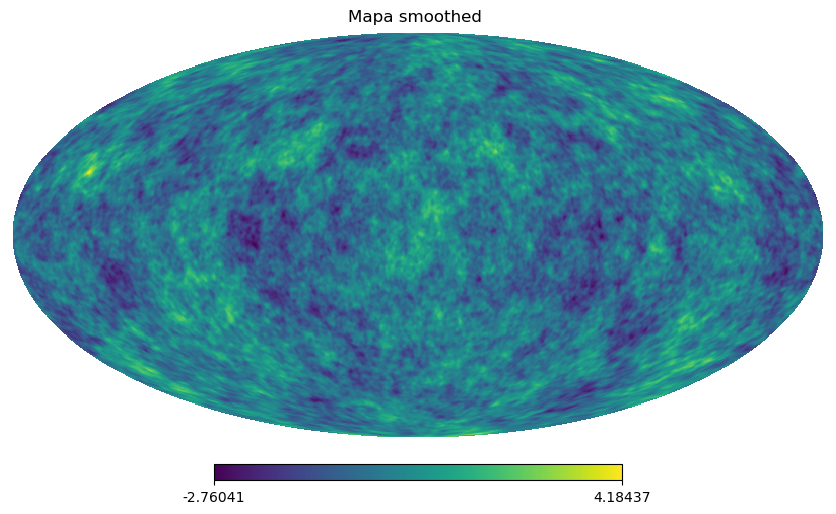

In [ ]:
## Suavizar mapas, hacer un beam smoothing
# Esto es para quitar la resolucion de los mapas simulados ya que los telescopios tienen un haz angular (beam) que difumina la imagen
# Aqui lo hacen gaussiano


m_smoothed = hp.smoothing(m, fwhm=np.radians(1.))  # Depende del Telescopio

hp.mollview(m_smoothed, title="Mapa smoothed ")

# USAR MPI para simulaciones realmentes complejas

MPI = Messaje passing interface

Sirve para ejecutar un mismo programa en varios procesos simultaneamente, ayuda que el calculo de los mapas sea mas rapido y que el smoothing sea mas distribuido.

Por asi decirlo separa el trabajo, veremos mas adelante un ejemplo.

Ex: Se escribe en la terminal y le indica que corra el codigo python en 8 procesos separados c/u con una parte del mapa.

mpirun -n 8 python script.py

!mpirun -n 8 python mi_notebook.py

Se deben distribuir los pixeles entre procesos:

map_dist = pysm.MapDistribution(
    pixel_indices=None, nside=nside, mpi_comm=MPI.COMM_WORLD
)

# Mini tutorial de usar pysm3

AQUI DEBO ESTUDIAR EN QUE CONSISTEN CADA UNA DE ESTAS SIMULACIONES DE FOREGROUNDS.

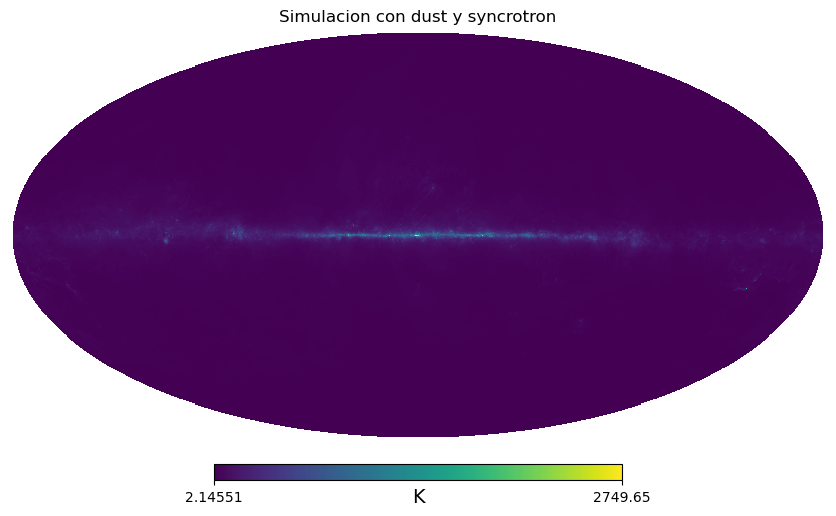

In [ ]:
import pysm3 as pysm
import pysm3.units as u


map_dist = pysm.MapDistribution(pixel_indices=None, nside=nside, mpi_comm=MPI.COMM_WORLD)


# Crear un cielo fisico con modelos d1 polvo, s1 sincrotron, f1 free-free, a1 anomalous dust emission
sky = pysm.Sky(nside=nside, preset_strings=["d1", "s1"], map_dist=map_dist)

# Obtener la emision del cielo, retorna  I [0], Q [1] y U [2]
# IMPORTANTE freq: es el rango de frecuencias con el que sacara 1 mapa
# y weights los pesos son asignados a cada uno de esos mapas en cada frecuencia digamos porque los 
# detectores son mas sensibles cerca de una frecuencia dada que en los bordes. 'como un instrumento real'

m = sky.get_emission(
    freq=np.arange(50, 55) * u.GHz,
    weights=np.array([0.1, 0.3, 0.5, 0.3, 0.1])
)[0]

hp.mollview(m,title="Simulacion con dust y syncrotron", unit="K")

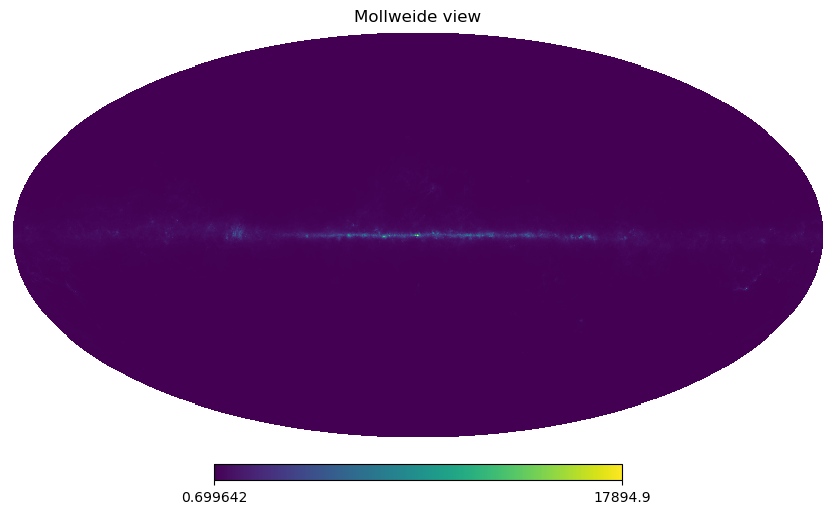

In [ ]:
# Crear un cielo fisico con modelos d1 polvo, s1 sincrotron, f1 free-free, a1 anomalous dust emission
sky = pysm.Sky(nside=nside, preset_strings=["d1", "s1","f1","a1"], map_dist=None)

m = sky.get_emission(
    freq=np.arange(130, 135) * u.GHz,
    weights=np.array([0.1, 0.3, 0.5, 0.3, 0.1])
)[0]

hp.mollview(m)

In [ ]:
#Suavizar el mapa 
# SE NECESITA PRE INSTALAR LIBSHARP VER DOC DE PYSM3...

m_smoothed = pysm.apply_smoothing_and_coord_transform(
    m, fwhm=1 * u.deg, map_dist=map_dist
)

NameError: name 'map_dist' is not defined

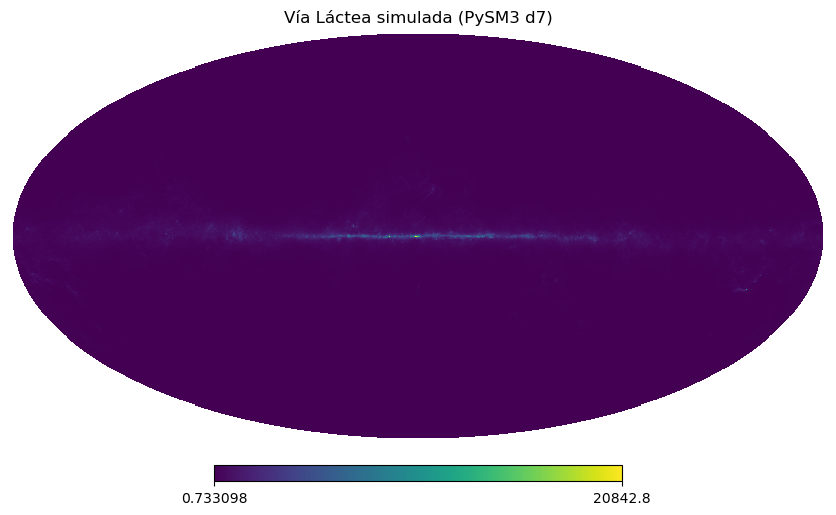

In [ ]:
nside = 512

sky = pysm3.Sky(
    nside=nside,
    preset_strings=["d7", "s1"],   # polvo grueso + sincrotron
)

# Frecuencia observada (por ejemplo 150 GHz)
freq = np.array([150.0]) * u.GHz

m = sky.get_emission(freq)[0]   # I map

hp.mollview(m, title="Vía Láctea simulada (PySM3 d7)")
#hp.graticule()


# CAMB + Pysm3 + Healpy 


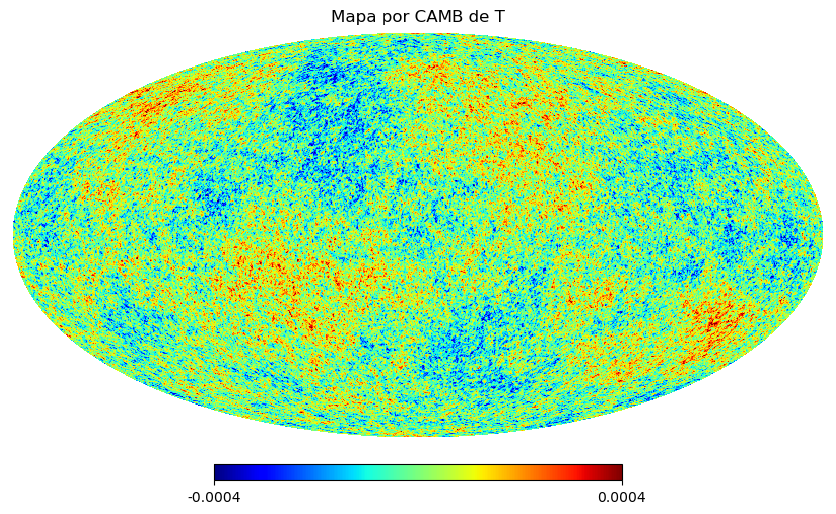

In [ ]:
####  Generamos la señal del CMB #####

#Parametros cosmologicos:
H0 = 67.66 # km/s/Mpc 
omega_m = 0.3111 # parametro de densidad de materia
omega_ch2 = 0.11933 # parametro de densidad de materia oscura
omega_bh2 = 0.02242 # parametro de densidad de bariones
ns = 0.9665 # indice escalar espectral 
tau = 0.0561 #optical depth
r = 0.1

# Creamos un objeto donde guardaremos los parámetros cosmológicos
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0,ombh2=omega_bh2, omch2=omega_ch2, tau=tau)
pars.InitPower.set_params(ns=ns, r=r) # parametros de inflacion r, As,...

# Activar tensores (IMPORTANTE)
pars.WantTensors = True
pars.Want_CMB_lensing = True
                                                 
#CAMB por defecto calcula hasta l = 2500 para modificarlo se usa:
pars.set_for_lmax(2500, lens_potential_accuracy=1)

# Ahora, para obtener resultados
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, lmax=2500, CMB_unit='K', spectra=['total', 'unlensed_scalar', 'lens_potential'], raw_cl=True)
clphi = results.get_lens_potential_cls()

#llamamos los distintos Cls que nos entrega
unlensed_Cl = powers['unlensed_scalar']
total_Cl = powers['total']
lens_potential_Cl = powers['lens_potential']

ells = np.arange(total_Cl[:, 0].shape[0])

# Generamos los mapas con el power spectrum total

Cl_TT = total_Cl[:,0]

Cl_EE = total_Cl[:,1]

Cl_BB = total_Cl[:,2]

Cl_TE = total_Cl[:,3]

#Generamos los mapas correspondientes.

nside = 1024  # buena resolución estándar

cmb_map_TT = hp.synfast(Cl_TT, nside=nside, lmax=2500, new=True)

cmb_map_EE = hp.synfast(Cl_EE, nside=nside, lmax=2500, new=True)

cmb_map_BB = hp.synfast(Cl_BB, nside=nside, lmax=2500, new=True)

cmb_map_TE = hp.synfast(Cl_TE, nside=nside, lmax=2500, new=True)

hp.mollview(cmb_map_TT, title="Mapa por CAMB de T", min=-0.0004, max=0.0004, cmap= 'jet')

In [65]:
a=(0,1,2,3,4,5,6,7,8)
a[3:]

(3, 4, 5, 6, 7, 8)

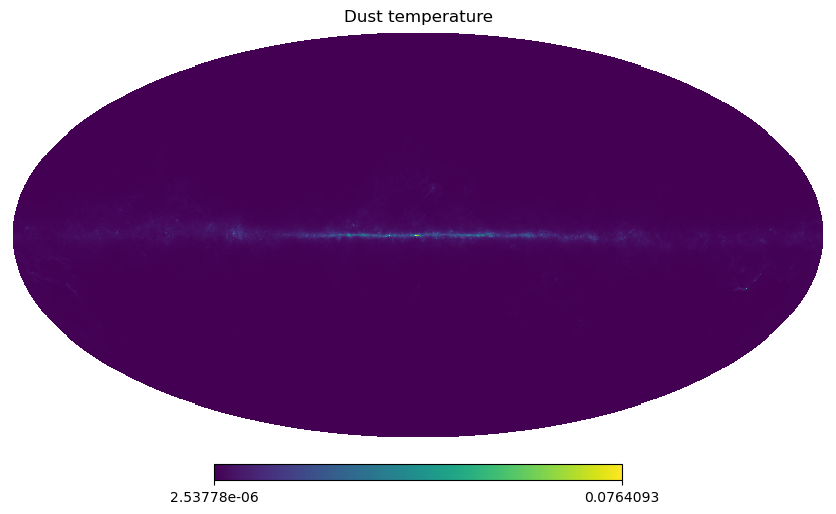

In [ ]:
#### Generamos mapas con foregrounds con PYSM3 #####

nside = 512 

# Crear un cielo fisico con modelos d1 polvo, s1 sincrotron, f1 free-free, a1 anomalous dust emission
sky = pysm.Sky(nside=nside, preset_strings=["d1"],output_unit="K_CMB") 
# vector de frecuencias que queremos los mapas de foregrounds
freq = np.array([30, 70, 143, 220,545])

map_30 = sky.get_emission(freq[0]*u.GHz) #tiene I, Q y U
map_70 = sky.get_emission(freq[1]*u.GHz)
map_143 = sky.get_emission(freq[2]*u.GHz)
map_220 = sky.get_emission(freq[3]*u.GHz)
map_545= sky.get_emission(freq[4]*u.GHz)

hp.mollview(map_220[0], title="Dust temperature")

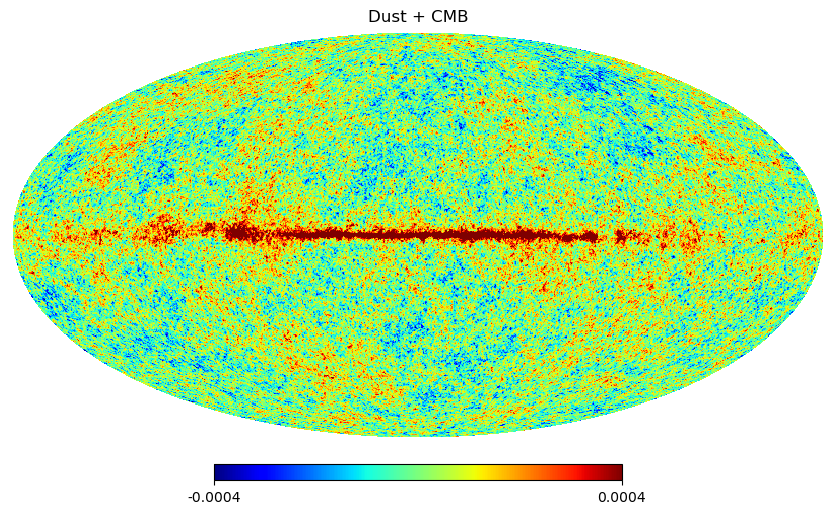

In [ ]:
### Sumamos CAMB y Foregrounds para Temperatura ###

map_30_tot = np.array(map_30[0]) + np.array(cmb_map_TT)
map_70_tot = np.array(map_70[0]) + np.array(cmb_map_TT)
map_143_tot = np.array(map_143[0]) + np.array(cmb_map_TT)
map_220_tot = np.array(map_220[0]) + np.array(cmb_map_TT)
map_545_tot = np.array(map_545[0]) + np.array(cmb_map_TT)


hp.mollview(map_70_tot, title="Dust + CMB", min=-0.0004,max=0.0004, cmap = "jet")

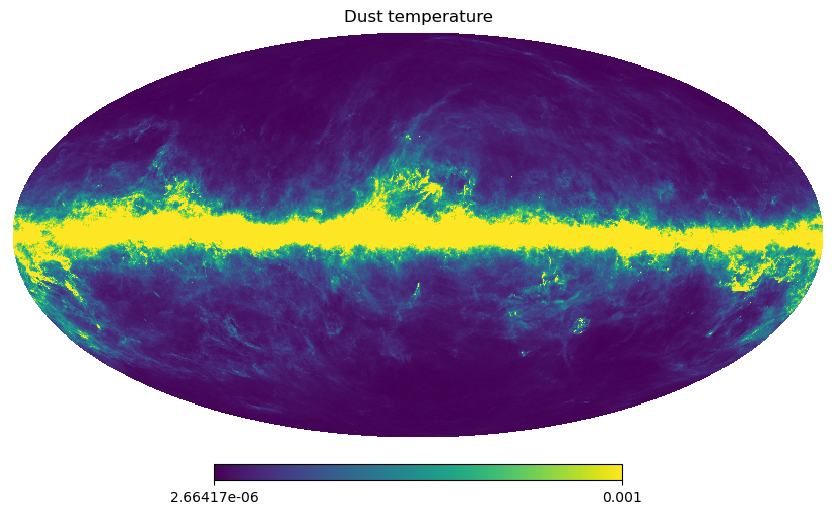

In [ ]:
nside = 512 

# Crear un cielo fisico con modelos d1 polvo, s1 sincrotron, f1 free-free, a1 anomalous dust emission
sky = pysm.Sky(nside=nside, preset_strings=["d1", "s1"],output_unit="K_CMB") 
# vector de frecuencias que queremos los mapas de foregrounds
freq = np.array([30, 70, 143, 220,545])

map_30 = sky.get_emission(freq[0]*u.GHz) #tiene I, Q y U
map_70 = sky.get_emission(freq[1]*u.GHz)
map_143 = sky.get_emission(freq[2]*u.GHz)
map_220 = sky.get_emission(freq[3]*u.GHz)
map_545= sky.get_emission(freq[4]*u.GHz)

hp.mollview(map_220[0], title="Dust temperature", max=0.001)

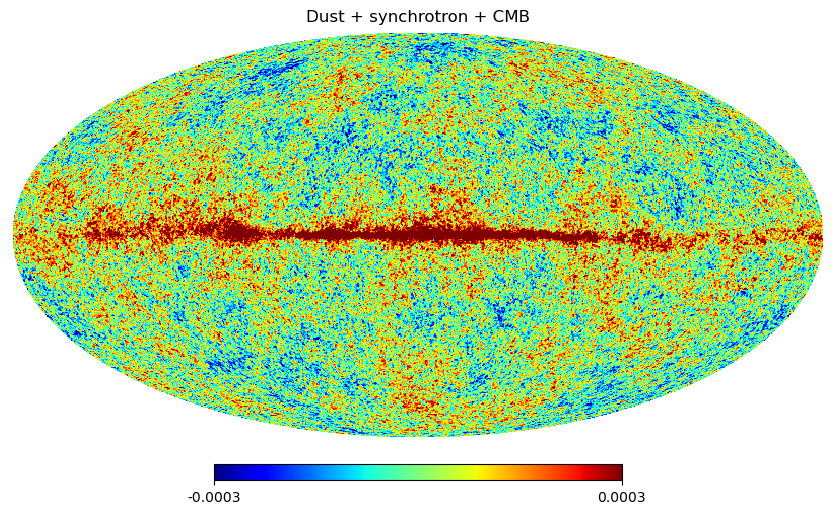

In [ ]:
### Sumamos CAMB y Foregrounds para Temperatura ###

map_30_tot = np.array(map_30[0]) + np.array(cmb_map_TT)
map_70_tot = np.array(map_70[0]) + np.array(cmb_map_TT)
map_143_tot = np.array(map_143[0]) + np.array(cmb_map_TT)
map_220_tot = np.array(map_220[0]) + np.array(cmb_map_TT)
map_545_tot = np.array(map_545[0]) + np.array(cmb_map_TT)


hp.mollview(map_70_tot, title="Dust + synchrotron + CMB",min = -0.0003, max=0.0003, cmap = "jet")

## Incorporar Ruido

La idea aqui es añadir el ruido de SO, que es definido en el documento de [The SO: Science goals and forecast](https://arxiv.org/pdf/1808.07445). En este definen $ N_\ell$, el cual sera la potencia del ruido por multipolo.

$$ N_\ell = N_{red} \left ( \frac{\ell}{\ell_{knee}}\right)^{\alpha_{knee}} + N_{white}$$

* $N_{white}$ corresponde al ruido blanco relacionado al instrumento **Gaussiano**
* $ N_{red} \left ( \frac{\ell}{\ell_{knee}}\right)^{\alpha_{knee}} $ este termino modela la contribucion de ruido por $1/f$ **No entiendo como pasan de un error de frecuencia a uno expresado en multipolos**
    * $\ell_{knee}$ es el multipolo de corte, donde 1/f empieza a dominar.
    * $\alpha_{knee}$ es la potencia con la que aumenta el ruido.

En SO usan lo siguientes valores:


![Captura desde 2025-12-06 09-41-06.png](./images/Noise2_SO.png)

![image.png](./images/Noise1_SO.png)

Con esto en mente lo añadiremos a mano.

**AHORA COMO LO HAGO? ME ENREDE EN EL $N_{Red}$ TIENE UNIDADES DE TIEMPO COMO LO PASO A ARCMIN**

[tutorial de agregar ruido y hablan de ese muK s](https://www.zonca.dev/index.html#category=cosmology)




In [ ]:
# Frecuencia 145 para LAT

# parametros

nside = 512
ellmax = 3*nside - 1
noise_white = 10 # en unidades muK-arcmin
ell_knee = 50
alpha = -3
seed = 12345 #reproducibilidad

#pasamos de muK-arcmin -->

# CMB Map Analisis

Para esta parte seguire lo que se muestra en el siguiente paper: [HERE](https://arxiv.org/pdf/2410.12951v1)

El side-length resolution (resolucion de largo lateral??) del pixel $\theta_r$ de una particular $N_{side}$ se puede aproximar en radianes:

$$ \theta_r = \sqrt{\frac{4 \pi}{N_{pix}}} = \sqrt{\frac{4 \pi}{12N_{side}}} $$

Además, como sabemos la varianza cosmica es:

$$ \sigma^2_{cos} = Var(\tilde{C}_{\ell}^{XY}) = \frac{2}{2\ell + 1}(C_{\ell}^{XY})^2 $$
 
Pero cuando nosotros observamos un parche en el cielo, la varianza crece, por un factor de $4 \pi/ f_{sky}$. Esta nueva varianza es llamada sample variance (varianza muestral?) y es demostrado en el siguiente [paper](https://arxiv.org/pdf/astro-ph/9305030).

$$ \sigma^2_{sam} \simeq (4 \pi / f_{sky})\sigma^2_{cos}$$
 
Donde $f_{sky}$ es el angulo solido cubierto por el instrumento.

**El BEAM** se aproxima gaussiano, por lo que tendrá un full-width-at-half-maximum (FWHM). Su efecto en el power spectrum es amortiguar los $\ell_s$ mas grandes, y como la convolucion en el espacio de fourier se observa como una multiplicacion, el beam gaussiano $B_\ell$ con una desviacion estandar $\sigma$:

$$ FWHM = \sqrt{8ln(2)}\sigma $$
$$ B_\ell =e^{-\frac{1}{2}\ell (\ell + 1)\sigma^2} $$
$$ {}_2B_\ell =e^{-\frac{1}{2}\ell (\ell + 1)\sigma^2} e^{2\sigma^2}$$
$$ C^{obs}_\ell = B_\ell^2C_\ell$$

Donde la 3era ecuacion corresponde a una aproximacion del beam en mapas de polarizacion.

**THE PIXEL-WINDOW FUNCTION** modela como se promedian las observaciones del cielo en pixeles


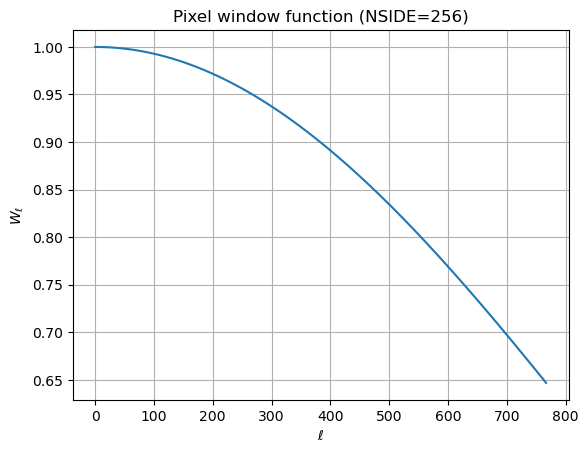

In [ ]:
w_ell = hp.pixwin(nside, lmax=lmax)

plt.plot(w_ell)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$W_\ell$')
plt.title(f'Pixel window function (NSIDE={nside})')
plt.grid(True)
plt.show()


Ayuda para healpix de plotear mapas [aqui](https://www.zonca.dev/posts/2020-09-30-planck-spectra-healpy.html)

AQUI SE HABLA DE CAR y Healpix y como graficar mapas de SO creo [AQUI](https://pspy.readthedocs.io/en/latest/notebooks/tutorial_io.html)

[DOCUMENTACION HEALPY](https://healpy.readthedocs.io/en/latest/)

In [1]:
help(hp)

NameError: name 'hp' is not defined

## VERIFICAR QUE LA SEMILLA DEL POTENCIAL CON LA DE MIS OTROS MAPAS SEAN CORRESPONDIENTES

ES DECIR LENSEAR EL PARA UNLENSED CON EL POTENCIAL DE LENSING Y RECUPERAR EL MAPA TOTAL

In [60]:
np.array(map_30[0])

array([0.20494866, 0.17811611, 0.17749498, ..., 0.22586956, 0.23282891,
       0.20564257])

In [72]:
a = (1,2,3,4,5,6,7,8,9)
a[2:]
c = np.zeros(len(a))
c

array([0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [73]:
sky = pysm.Sky(nside=nside, preset_strings=["d1"], map_dist=None)


In [74]:
sky.components[0].__class__



pysm3.models.dust.ModifiedBlackBody

In [75]:
print(pysm3.models.dust.ModifiedBlackBody.__init__.__doc__)



 This function initializes the modified black body model.

        The initialization of this model consists of reading in emission
        templates from file, reading in spectral parameter maps from
        file.

        Parameters
        ----------
        map_I, map_Q, map_U: `pathlib.Path` object
            Paths to the maps to be used as I, Q, U templates.
            If has_polarization is True and map_Q is None, assumes map_I is IQU
        unit_* : string or Unit
            Unit string or Unit object for all input FITS maps, if None, the input file
            should have a unit defined in the FITS header.
        freq_ref_I, freq_ref_P: Quantity or string
            Reference frequencies at which the intensity and polarization
            templates are defined. They should be a astropy Quantity object
            or a string (e.g. "1500 MHz") compatible with GHz.
        map_mbb_index: `pathlib.Path` object or scalar value
            Path to the map to be used as the po